# MNIST 손글씨 숫자 이미지 분류

## 실습 목표
본 실습에서는 MNIST 손글씨 숫자 이미지 데이터셋을 이용하여 다층 퍼셉트론(MLP) 기반 분류 모델을 구현하고, 학습 결과를 분석한다.

## 실습 내용
- MNIST 데이터셋 불러오기
- 데이터 전처리 및 학습/검증 데이터 분리
- 다층 퍼셉트론 모델 구성
- 모델 학습 및 성능 평가
- 예측 결과 확인
- 혼동행렬(Confusion Matrix)과 분류 리포트(Classification Report) 분석

---

#### 1] 라이브러리 import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from typing import Any
from tensorflow.keras.datasets.mnist import load_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

#### 2] 상수 정의

In [2]:
RANDOM_STATE = 777
NUM_CLASSES = 10
IMAGE_SIZE = 28 * 28
EPOCHS = 30
BATCH_SIZE = 128
VALIDATION_RATIO = 0.3

## 데이터셋 소개

- MNIST 데이터셋은 0부터 9까지의 손글씨 숫자 이미지로 구성된 대표적인 이미지 분류 데이터셋이다.  
- 각 이미지는 `28 × 28` 크기의 흑백 이미지이며, 총 10개의 클래스로 구성된다.
- MNIST는 이미지 분류 입문 단계에서 자주 사용되는 데이터셋으로, 비교적 단순한 구조의 모델로도 높은 성능을 얻을 수 있다.

#### 3] 데이터 준비 함수

##### 데이터 전처리

모델 학습을 위해 다음과 같은 전처리를 수행한다.

1. 학습 데이터를 학습용(train)과 검증용(validation)으로 분리
2. 이미지 데이터를 1차원 벡터 형태로 reshape
3. 픽셀 값을 `0 ~ 255` 범위에서 `0 ~ 1` 범위로 정규화
4. 레이블을 one-hot encoding 형태로 변환

이 과정을 통해 모델이 데이터를 더 안정적으로 학습할 수 있도록 한다.

In [3]:
def load_and_prepare_data(validation_ratio: float = VALIDATION_RATIO, random_state: int = RANDOM_STATE) -> tuple:
    (x_train, y_train), (x_test, y_test) = load_data(path='mnist.npz')

    x_train, x_val, y_train, y_val = train_test_split(
        x_train,
        y_train,
        test_size=validation_ratio,
        random_state=random_state
    )

    x_train = x_train.reshape((-1, IMAGE_SIZE)).astype('float32') / 255.0
    x_val = x_val.reshape((-1, IMAGE_SIZE)).astype('float32') / 255.0
    x_test = x_test.reshape((-1, IMAGE_SIZE)).astype('float32') / 255.0

    y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_val = to_categorical(y_val, num_classes=NUM_CLASSES)
    y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

    return x_train, x_val, y_train, y_val, x_test, y_test

#### 4] 샘플 이미지 확인 함수

##### 샘플 이미지 확인

- 학습에 사용될 이미지 데이터를 시각적으로 확인하여 데이터가 정상적으로 불러와졌는지 점검한다.  
- 무작위로 선택한 샘플 이미지를 통해 각 숫자 이미지의 형태를 살펴볼 수 있다.

In [4]:
def show_random_samples(images: np.ndarray, labels: np.ndarray,
                        sample_size: int = 3, random_state: int = RANDOM_STATE) -> None:

    rng = np.random.default_rng(random_state)
    random_idx = rng.choice(len(images), size=sample_size, replace=False)

    fig, axes = plt.subplots(1, sample_size, figsize=(12, 4))

    for i, idx in enumerate(random_idx):
        axes[i].imshow(images[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title(f'Index: {idx}\nLabel: {labels[idx]}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

#### 5] 모델 생성 함수

##### 모델 구성

- 본 실습에서는 다층 퍼셉트론(MLP) 구조를 사용한다.  
- 입력 데이터는 `28 × 28` 형태의 이미지를 1차원 벡터(784차원)로 변환한 후, 여러 개의 Dense 층을 통과하여 최종적으로 10개의 클래스에 대해 Softmax 확률값을 출력한다.
- MNIST는 비교적 단순한 이미지 분류 문제이므로, 기본적인 MLP 구조만으로도 높은 성능을 기대할 수 있다.

In [5]:
def build_dense_model(hidden_units: list[int]) -> Sequential:
    model = Sequential([
        Input(shape=(IMAGE_SIZE,)),
        *[Dense(units, activation='relu') for units in hidden_units],
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#### 6] 학습 함수

##### 모델 학습

모델은 다음과 같은 학습 조건에서 학습을 수행한다.

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy
- Epochs: 30
- Batch Size: 128

검증 데이터(validation data)를 함께 사용하여 epoch별 손실과 정확도를 추적한다.

In [6]:
def train_model(
    model: Sequential,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE
):
    return model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=0
    )

#### 7] 학습 결과 시각화 함수

##### 학습 결과 시각화

학습 과정에서 기록된 손실(loss)과 정확도(accuracy)를 그래프로 시각화하여 모델의 학습 추이를 확인한다.

이를 통해 다음과 같은 내용을 확인할 수 있다.

- 학습이 정상적으로 진행되는지 여부
- 과적합(overfitting) 발생 여부
- 학습 데이터와 검증 데이터의 성능 차이

In [7]:
def plot_history(history: Any, title_prefix: str = 'MNIST Model') -> None:
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    acc_key = 'accuracy' if 'accuracy' in hist else 'acc'
    val_acc_key = f'val_{acc_key}'

    sns.set_theme(style='whitegrid', context='notebook')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.lineplot(x=list(epochs), y=hist[acc_key], ax=axes[0], label='train_accuracy')
    sns.lineplot(x=list(epochs), y=hist[val_acc_key], ax=axes[0], label='val_accuracy')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')

    sns.lineplot(x=list(epochs), y=hist['loss'], ax=axes[1], label='train_loss')
    sns.lineplot(x=list(epochs), y=hist['val_loss'], ax=axes[1], label='val_loss')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

#### 8] 예측 결과 확인 함수

##### 예측 결과 확인

- 테스트 데이터에 대한 클래스별 예측 확률과 최종 예측 클래스를 확인한다.  
- 일부 샘플에 대해 예측 결과를 직접 확인하고, 이미지와 함께 비교할 수 있다.

In [8]:
def show_prediction_probabilities(predictions: np.ndarray, sample_indices: list[int]) -> None:
    for idx in sample_indices:
        pred_class = np.argmax(predictions[idx])

        print(f'[테스트 데이터 index: {idx}]')
        for class_idx, prob in enumerate(predictions[idx]):
            print(f'클래스 {class_idx}: {prob * 100:6.2f}%')
        print(f'예측한 클래스: {pred_class}')
        print('-' * 40)

In [9]:
def show_prediction_samples(
    images: np.ndarray,
    predictions: np.ndarray,
    true_labels: np.ndarray | None = None,
    sample_size: int = 3,
    random_state: int | None = None
) -> None:

    if random_state is None:
        indices = np.arange(sample_size)
    else:
        rng = np.random.default_rng(random_state)
        indices = rng.choice(len(images), size=sample_size, replace=False)

    pred_labels = np.argmax(predictions, axis=1)

    fig, axes = plt.subplots(1, sample_size, figsize=(12, 4))

    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx].reshape(28, 28), cmap='gray')

        if true_labels is not None:
            title = f'Pred: {pred_labels[idx]}\nTrue: {true_labels[idx]}'
        else:
            title = f'Pred: {pred_labels[idx]}'

        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
def plot_confusion_matrix(y_true: np.ndarray, predictions: np.ndarray) -> None:
    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(predictions, axis=1)

    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(7, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('predicted label')
    plt.ylabel('true label')
    plt.title('Confusion Matrix')
    plt.show()

---

#### 데이터 로드 및 확인

전처리 함수를 이용하여 MNIST 데이터를 불러오고, 학습용·검증용·테스트용 데이터의 shape를 확인한다.

In [11]:
x_train, x_val, y_train, y_val, x_test, y_test = load_and_prepare_data()

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_val:', x_val.shape)
print('y_val:', y_val.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

x_train: (42000, 784)
y_train: (42000, 10)
x_val: (18000, 784)
y_val: (18000, 10)
x_test: (10000, 784)
y_test: (10000, 10)


#### 샘플 이미지 보기

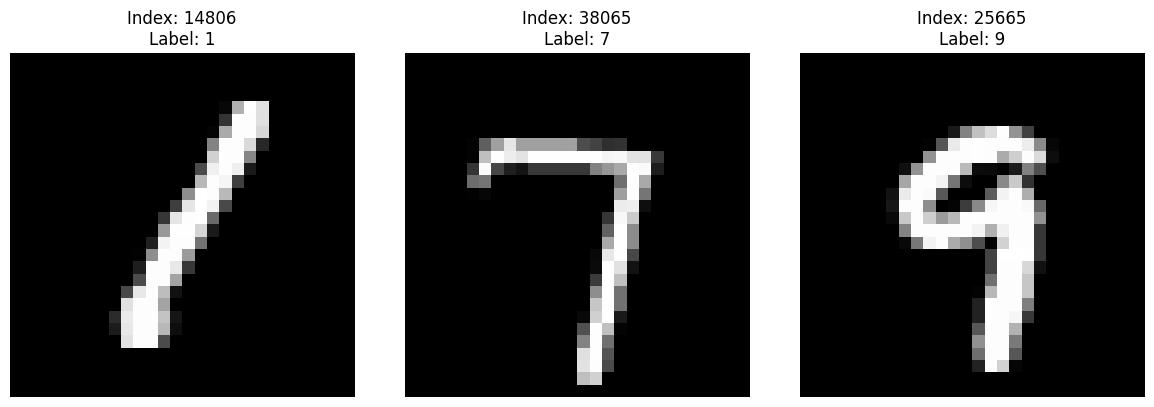

In [12]:
show_random_samples(
    images=x_train,
    labels=np.argmax(y_train, axis=1),
)

#### 모델 생성

##### 모델 정보

- 본 실습에서는 은닉층을 `[64, 32]` 형태로 구성한 기본적인 다층 퍼셉트론 모델을 사용하였다.  
- MNIST 데이터셋은 비교적 단순한 분류 문제이므로, 복잡한 구조 없이도 높은 정확도를 기대할 수 있다.

In [13]:
model = build_dense_model([64, 32])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

#### 모델 학습

In [14]:
history = train_model(model, x_train, y_train, x_val, y_val)

#### 결과 시각화

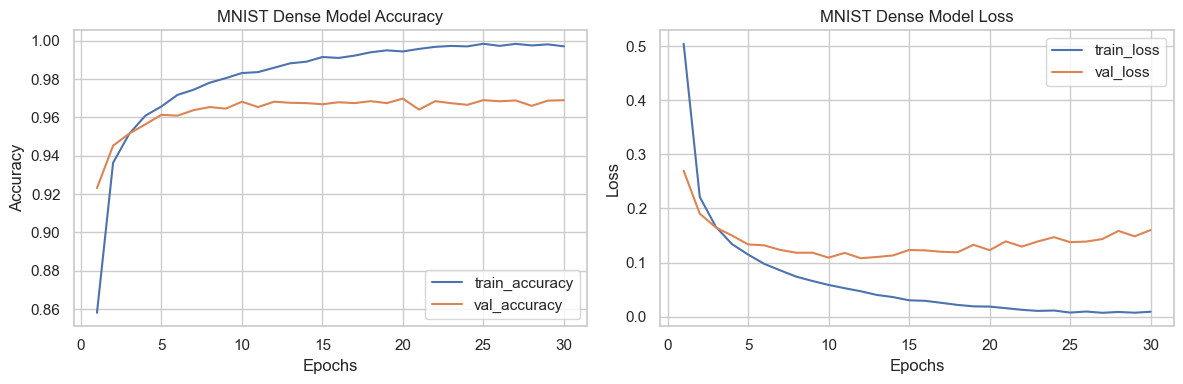

In [15]:
plot_history(history, title_prefix='MNIST Dense Model')

#### 테스트 데이터 평가

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.1563
Test Accuracy: 0.9678


#### 예측 수행 및 결과 확인

In [17]:
predictions = model.predict(x_test, verbose=0)
print('예측 결과 shape:', predictions.shape)

예측 결과 shape: (10000, 10)


In [18]:
show_prediction_probabilities(
    predictions=predictions,
    sample_indices=[0, 1, 2]
)

[테스트 데이터 index: 0]
클래스 0:   0.00%
클래스 1:   0.00%
클래스 2:   0.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.00%
클래스 7: 100.00%
클래스 8:   0.00%
클래스 9:   0.00%
예측한 클래스: 7
----------------------------------------
[테스트 데이터 index: 1]
클래스 0:   0.00%
클래스 1:   0.00%
클래스 2: 100.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.00%
클래스 7:   0.00%
클래스 8:   0.00%
클래스 9:   0.00%
예측한 클래스: 2
----------------------------------------
[테스트 데이터 index: 2]
클래스 0:   0.00%
클래스 1:  99.86%
클래스 2:   0.00%
클래스 3:   0.00%
클래스 4:   0.00%
클래스 5:   0.00%
클래스 6:   0.01%
클래스 7:   0.11%
클래스 8:   0.02%
클래스 9:   0.00%
예측한 클래스: 1
----------------------------------------


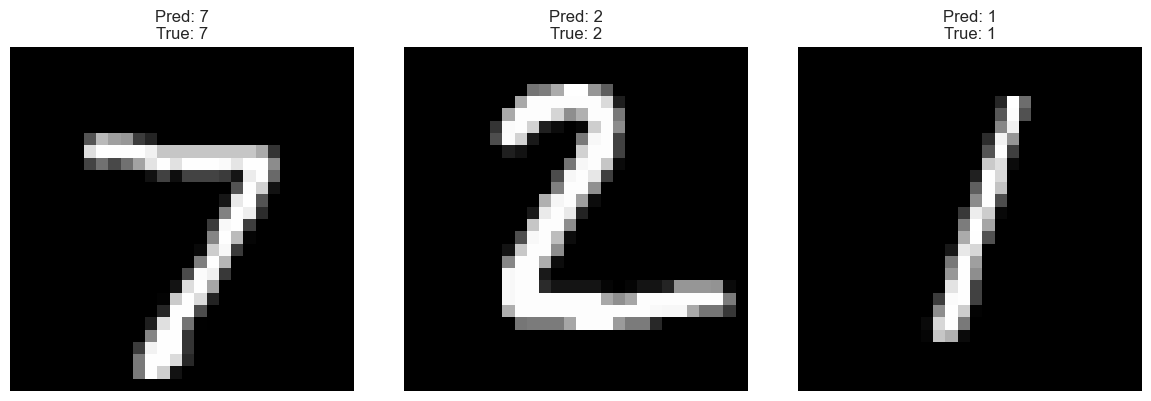

In [19]:
show_prediction_samples(
    images=x_test,
    predictions=predictions,
    true_labels=np.argmax(y_test, axis=1),
    sample_size=3
)

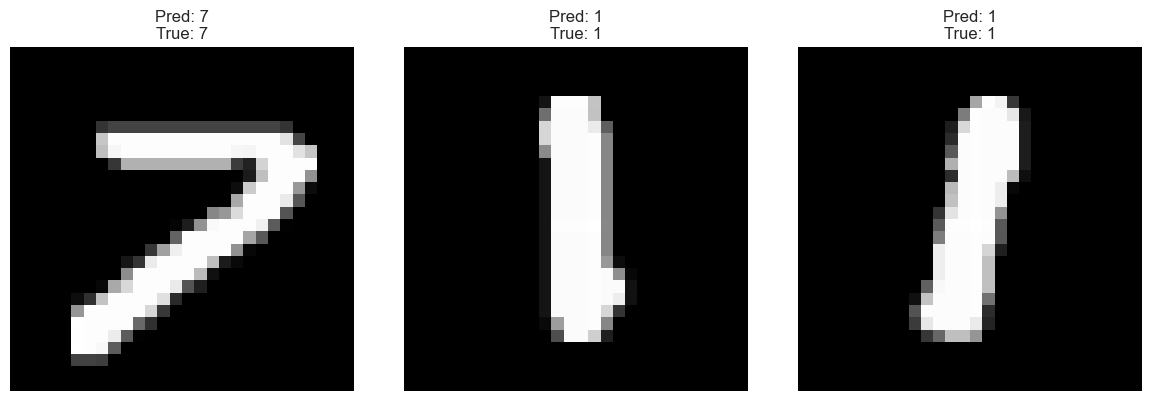

In [20]:
show_prediction_samples(
    images=x_test,
    predictions=predictions,
    true_labels=np.argmax(y_test, axis=1),
    sample_size=3,
    random_state=RANDOM_STATE
)

#### 혼동행렬 및 분류 리포트

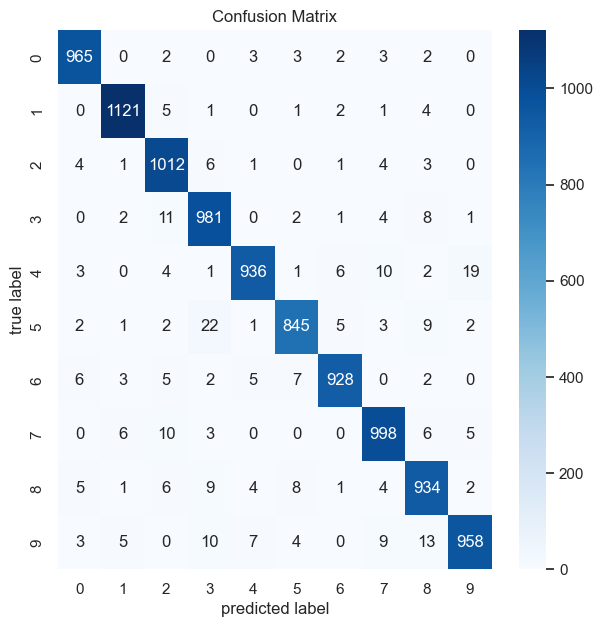

In [21]:
plot_confusion_matrix(y_test, predictions)

In [22]:
true_labels = np.argmax(y_test, axis=1)
pred_labels = np.argmax(predictions, axis=1)

print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.95      0.97       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.96      0.97      0.97      1028
           8       0.95      0.96      0.95       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 모델 학습 결과 분석

이번 실험에서는 MNIST 데이터셋을 이용하여 다층 퍼셉트론(MLP) 기반 분류 모델을 학습하고, 그 결과를 손실(Loss), 정확도(Accuracy), 혼동행렬, 분류 리포트를 통해 분석하였다.

### 1. 전체적인 학습 경향
학습 결과, train accuracy와 validation accuracy는 epoch가 증가함에 따라 빠르게 상승하였고, train loss와 validation loss는 감소하는 모습을 보였다. 이는 모델이 MNIST 데이터의 기본적인 패턴을 정상적으로 학습하고 있음을 의미한다.

### 2. 모델 성능
테스트 데이터 평가 결과 높은 정확도를 보였으며, 이는 비교적 단순한 MLP 구조만으로도 MNIST와 같은 기본적인 이미지 분류 문제를 효과적으로 해결할 수 있음을 보여준다.

### 3. 예측 결과 해석
일부 테스트 데이터의 클래스별 확률을 확인한 결과, 모델은 대부분의 샘플에서 특정 클래스에 높은 확률을 부여하며 명확한 예측을 수행하였다. 또한 예측 이미지와 실제 레이블을 함께 확인했을 때, 대부분의 샘플이 정확하게 분류되었음을 알 수 있었다.

### 4. 혼동행렬 및 분류 리포트
혼동행렬을 통해 대부분의 숫자가 정확히 분류되었음을 확인할 수 있었으며, 분류 리포트에서도 각 클래스별 precision, recall, f1-score가 전반적으로 높게 나타났다. 다만 일부 숫자는 형태가 유사하여 오분류가 발생할 수 있으며, 특히 획의 모양이 비슷한 숫자들 사이에서 혼동이 발생할 가능성이 있다.

### 5. 결론
이번 실습을 통해 다층 퍼셉트론 모델이 MNIST와 같은 손글씨 숫자 분류 문제에서 높은 성능을 보일 수 있음을 확인하였다. 이후에는 CNN(Convolutional Neural Network)과 같은 이미지 처리에 더 적합한 구조를 적용하여 성능을 비교해볼 수 있다.